# Preprocessing: from raw counts to the integrated single-cell atlas

**Takeshita M, Inamo J, et al. _Identification of a shared antigen linking CD4⁺ T and B cell pathology in Sjögren's disease._ Sci. Adv. (2026).**

This notebook documents the upstream processing of the salivary-gland scRNA-seq data. It consolidates:

### Processing overview
```
FASTQ  ->  Cell Ranger (count)  ->  CellBender (remove-background)
       ->  QC filtering + scDblFinder (doublet removal)
       ->  LogNormalize -> HVG -> ScaleData -> PCA
       ->  Harmony ->  kNN graph -> Louvain clusters -> UMAP
```


## 1. Ambient RNA removal — CellBender

Cell Ranger raw matrices were processed with **CellBender `remove-background`** (one SLURM array task per sample) to remove ambient/background RNA. The filtered output `cellbender_feature_bc_matrix_filtered.h5` is the input to QC.

```bash
#!/bin/sh
#SBATCH --array=1-8
#SBATCH --nodes=1 --ntasks=4 --cpus-per-task=4 --time=24:00:00

module load anaconda
conda activate cellbender        # pip install cellbender

seq_libs=(List LB183 LB189 LB214 LB215 LB216 LB219 LB220 LB221)
sample_id=${seq_libs[$SLURM_ARRAY_TASK_ID]}

DIR=.../SjS_Takeshita/JKiC/
data_type="GEX"
cd ${DIR}/data/${sample_id}/${data_type}/

cellbender remove-background \
        --input  raw_feature_bc_matrix.h5 \
        --output cellbender_feature_bc_matrix.h5 \
        --fpr 0.01 \
        --epochs 150 \
        --cpu-threads 4
```

Key parameters: false-positive rate `--fpr 0.01`, `--epochs 150`. Run on a GPU/CPU cluster; not executed here.

In [1]:
source("utils.R")
dir <- paste0(getwd(), "/../")
data_type <- "GEX"

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘ggpubr’ was built under R version 4.3.3”


## 2. Quality control and doublet removal

Per-sample CellBender matrices are read with `Read_CellBender_h5_Mat()`, converted to Seurat objects and merged. Cells are filtered on the number of detected genes and mitochondrial content, and **doublets called by `scDblFinder`** are removed.

The exact pipeline (run upstream; shown here for reference):
```r
# Build merged object from CellBender-cleaned matrices
successful_gex_list <- list()
for (sample_id in sample_ids) {
  gex.data <- Read_CellBender_h5_Mat(
      paste0(dir,'/data/',sample_id,'/GEX/cellbender_feature_bc_matrix_filtered.h5'))
  successful_gex_list[[sample_id]] <- CreateSeuratObject(counts = gex.data,
      project = paste0('GEX_', sample_id))
}
gex <- Merge_Seurat_List(successful_gex_list, add.cell.ids = names(successful_gex_list))

# Mitochondrial fraction
gex[['percent.mt']] <- PercentageFeatureSet(gex, pattern = '^MT-')

# QC thresholds (as used for the merged atlas)
gex <- subset(gex, subset = nFeature_RNA > 200)
gex <- subset(gex, subset = nFeature_RNA < 5000)
gex <- subset(gex, subset = percent.mt   < 20)

# Doublet detection with scDblFinder, then remove called doublets
gex <- scDblFinder(gex)            # run once; results cached in scDblFinderClass.txt
doublets <- read.table('output/scDblFinderClass.txt', header = TRUE) |>
  dplyr::filter(scDblFinder.class == 'doublet') |> dplyr::pull(barcode)
gex <- subset(gex, cells = doublets, invert = TRUE)
```

Below we load the resulting merged object and visualise the QC metrics and the doublet calls.

In [2]:
# Load the merged, QC-filtered atlas (output of the pipeline above).
gex <- readRDS(paste0(dir, "/output/SeuratObj_merged_", data_type, ".rds"))
gex <- JoinLayers(gex)
cat("cells x genes:", ncol(gex), "x", nrow(gex), "\n")
cat("cells per sample:\n"); print(table(gex$orig.ident))

cells x genes: 31218 x 36601 
cells per sample:

GEX_LB183 GEX_LB189 GEX_LB214 GEX_LB215 GEX_LB216 GEX_LB219 GEX_LB220 GEX_LB221 
     1831     11070      2284      2557      2770      7341      2833       532 


### QC metric distributions (post-filtering)

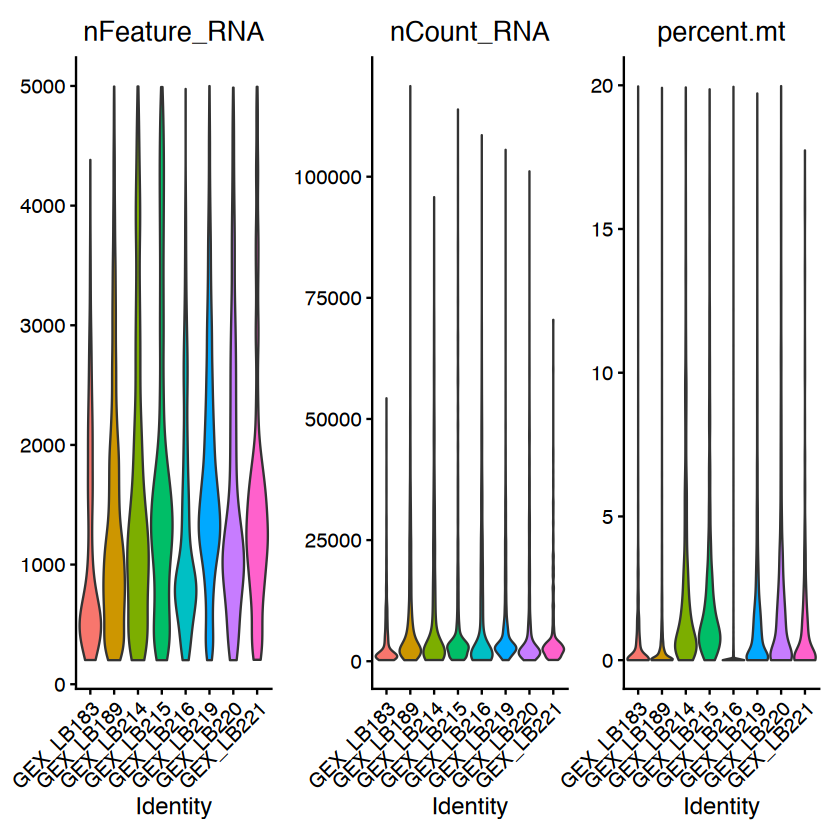

In [3]:
VlnPlot(gex, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
        group.by = "orig.ident", pt.size = 0, ncol = 3) &
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Doublet calls from scDblFinder

In [4]:
dbl <- read.table(paste0(dir, "/output/scDblFinderClass.txt"), header = TRUE)
cat("scDblFinder class counts (whole run, before doublet removal):\n")
print(table(dbl$scDblFinder.class))
cat(sprintf("\nDoublet rate: %.1f%%\n",
            100 * mean(dbl$scDblFinder.class == "doublet")))

scDblFinder class counts (whole run, before doublet removal):

doublet singlet 
    924   23882 

Doublet rate: 3.7%


## 3. Normalization, feature selection, scaling, PCA and Harmony

The merged object is log-normalized, the 2000 most variable genes are selected, the data are scaled and PCA is computed. Batch effects across samples are corrected with **Harmony**. This is the pipeline that produced the `harmony` reduction stored in the object (shown for reference; not re-run here, because re-running PCA/Harmony drifts across software versions):

```r
gex <- NormalizeData(gex, normalization.method = 'LogNormalize', scale.factor = 1e4)
gex <- FindVariableFeatures(gex, selection.method = 'vst', nfeatures = 2000)
gex <- ScaleData(gex, features = rownames(gex))
set.seed(1234); gex <- RunPCA(gex, features = VariableFeatures(gex))
set.seed(1234); gex <- RunHarmony(gex, 'orig.ident')   # batch = sample
```

## 4. Reproducing the published UMAP (Figure 1A)

The object already stores the paper's `harmony` embedding. Figure 1A was built from **Harmony dims 1:8** at **clustering resolution 0.1**. 

In [5]:
set.seed(1234)
gex <- FindNeighbors(gex, reduction = "harmony", dims = 1:8, k.param = 30, verbose = FALSE)
gex <- FindClusters(gex, resolution = 0.1, verbose = FALSE)
gex <- RunUMAP(gex, reduction = "harmony", dims = 1:8,
               n.neighbors = 30L, min.dist = 0.3, verbose = FALSE)
colnames(gex@reductions$umap@cell.embeddings) <- c("umap_1", "umap_2")
cat("clusters (resolution 0.1):\n"); print(table(Idents(gex)))

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by ‘BiocGenerics’



clusters (resolution 0.1):

    0     1     2     3     4     5     6     7     8     9 
10364  6135  5656  2098  2073  2058   870   801   611   552 


### Map the 10 clusters to broad cell types and draw Figure 1A

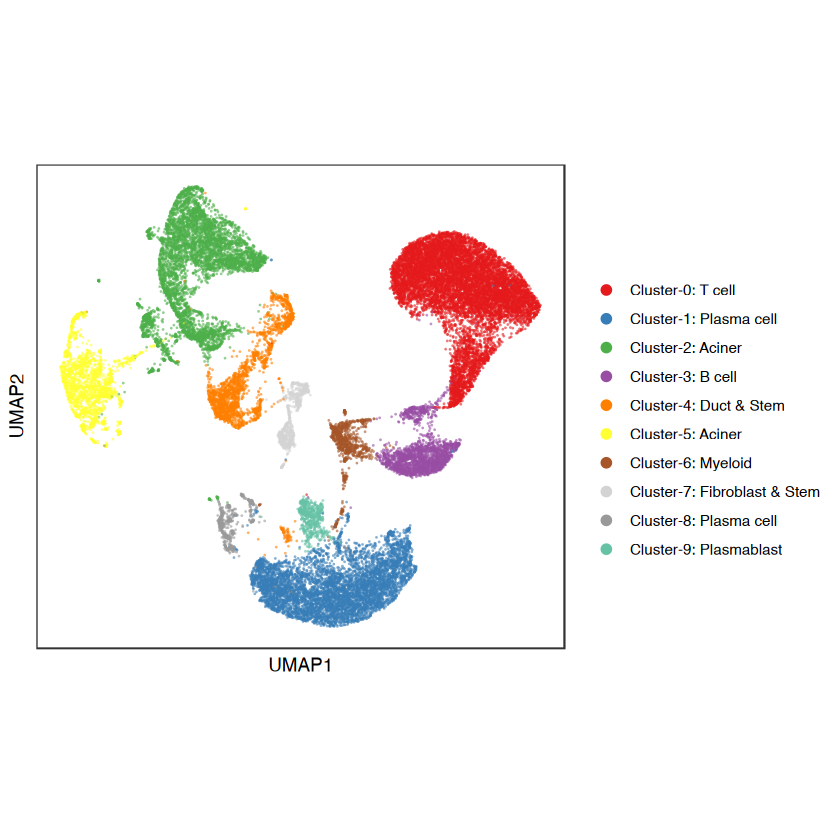

In [6]:
gex$new_cluster <- dplyr::case_when(
  gex$seurat_clusters %in% c("0")     ~ "T cell",
  gex$seurat_clusters %in% c("1","8") ~ "Plasma cell",
  gex$seurat_clusters %in% c("2","5") ~ "Aciner",
  gex$seurat_clusters %in% c("3")     ~ "B cell",
  gex$seurat_clusters %in% c("4")     ~ "Duct & Stem",
  gex$seurat_clusters %in% c("6")     ~ "Myeloid",
  gex$seurat_clusters %in% c("7")     ~ "Fibroblast & Stem",
  gex$seurat_clusters %in% c("9")     ~ "Plasmablast")

umap_df <- data.frame(gex[["umap"]]@cell.embeddings, cluster = Idents(gex),
                      cell_type = gex$new_cluster)

ggplot(umap_df[sample(nrow(umap_df)), ],
       aes(umap_1, umap_2, color = cluster)) +
  geom_point(size = 0.5, stroke = 0, shape = 16, alpha = 0.6) +
  scale_color_manual(values = manual_colors,
                     labels = paste0("Cluster-", levels(Idents(gex)), ": ",
                                     tapply(umap_df$cell_type, umap_df$cluster,
                                            function(x) x[1])[levels(Idents(gex))])) +
  coord_fixed() + labs(x = "UMAP1", y = "UMAP2", color = "") +
  theme_bw(base_size = 11) +
  theme(panel.grid = element_blank(), axis.text = element_blank(),
        axis.ticks = element_blank()) +
  guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))

## 5. Lineage sub-analyses

Downstream sub-clustering is documented in the other scripts:

- **T cells (Figure 1C–D) and the full TCR-repertoire analysis** → `02_figure_analysis.ipynb`
